In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb


In [43]:
# Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

In [44]:
# Defining the function that will use the model to complete the missing values
# Using the model to complete the test dataset

def complete_dataset(model_name, model):

    test_dataset = pd.read_csv('data/test_dataset.csv')

    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred
    test_dataset.head()

    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)

    # Creating a RowId column to store the index, starting from 1
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)

    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]

    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()

    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [45]:
# Define features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

## Random Forest

In [46]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np

# Drop the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])

# Define the hyperparameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 6, 12, 20, None]
}

# Initialize base model
base_rf = RandomForestClassifier(random_state=123)

oversampling_indicator = train_dataset['oversampled']

# Get indices for non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initialize StratifiedKFold for non-oversampled data
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)

# Create custom split indices that include oversampled data in training
custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices], 
    y.loc[non_oversampled_indices]
):
    # Get the actual indices from non_oversampled_indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

# Initialize RandomizedSearchCV with custom splits
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=custom_splits,
    scoring='f1_macro',
    random_state=123,
    n_jobs=-1,
    verbose=1
)

# Fit the random search
random_search.fit(X, y)

# Get the best model
best_rf = random_search.best_estimator_

# Initialize array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))

# Perform final cross-validation with best model
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    # Train best model on combined data (original + oversampled)
    best_rf.fit(X.loc[train_idx], y.loc[train_idx])
    
    # Predict on validation set (non-oversampled only)
    val_pred = best_rf.predict(X.loc[val_idx])
    
    # Store predictions
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred

# Calculate final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('Random Forest Classifier Results:')
print('Best Parameters:', random_search.best_params_)
print('Best Cross-Validation Score:', random_search.best_score_)
print('Final Macro F1 Score:', f1_macro)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Random Forest Classifier Results:
Best Parameters: {'n_estimators': 50, 'max_depth': 20}
Best Cross-Validation Score: 0.46098406333649294
Final Macro F1 Score: 0.4879094459713583


Confusion matrix
[[73  5  2  4 12]
 [ 4 30  0 18  8]
 [ 3  0  6  1  0]
 [13 21  0 22 12]
 [34  9  0 11 17]]


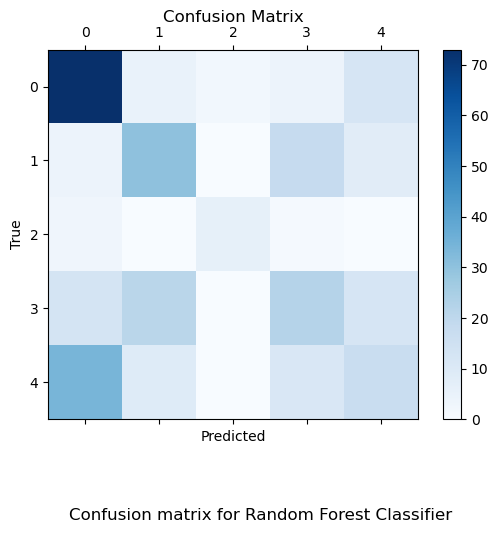

In [47]:
# Define non-oversampled target values
y_non_oversampled = y.loc[non_oversampled_indices]

# Define predictions from Random Forest Classifier
rfc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, rfc_pred))
# Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [48]:
# Printing the classification report

#print("Classification report")
#print(classification_report(y_val, rfc_pred))

In [49]:
# Completing the test dataset
complete_dataset('RandomForestClassifier', best_rf)

## XGBoost

In [50]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
from collections import Counter

oversampling_indicator = train_dataset['oversampled']
n_splits = 10
random_state = 123
# Initialize XGBoost with best parameters
xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=random_state,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)

# Get indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# Initialize array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))

# Perform cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Get the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Monitor class distribution in this fold's validation set
    fold_dist = Counter(y.loc[actual_val_idx])
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Train model on combined data (original + oversampled)
    xgbc.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predict on validation set (non-oversampled only)
    val_pred = xgbc.predict(X.loc[actual_val_idx])
    
    # Store predictions
    predictions[val_idx] = val_pred
    
# Calculate final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal XGBoost Classifier')
print(f'Overall Macro F1 Score: {f1_macro:.3f}')


Final XGBoost Classifier
Overall Macro F1 Score: 0.454


Confusion matrix
[[76  4  1  4 11]
 [ 4 25  0 20 11]
 [ 3  0  5  1  1]
 [13 24  0 22  9]
 [31  9  1 15 15]]


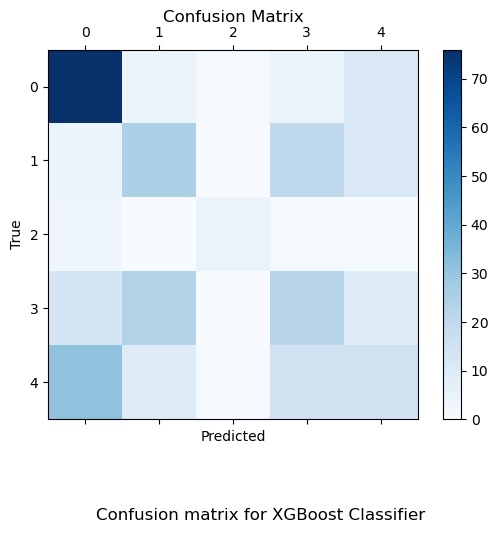

In [51]:
# Define predictions from XGBoost Classifier
xgbc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, xgbc_pred))
# Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, xgbc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for XGBoost Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [52]:
# Printing the classification report
#print("Classification report")
#print(classification_report(y_val, xgbc_pred))

In [53]:
# Completing the test dataset
complete_dataset('xgboost', xgbc)